Import necessary libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

🔹 Section 1: Define 3D world points

    Definition:
      # These represent points in real-world 3D space, used to simulate camera projection.

    Importance:
      # Needed to simulate how 3D objects are projected into a 2D image via a camera.

In [22]:
world_points = np.array([
    [0, 0, 0],      # Origin
    [1, 0, 0],      # X-axis
    [0, 1, 0],      # Y-axis
    [0, 0, 1],      # Z-axis
    [1, 1, 1],      # Diagonal point
]).T  # (3, N)
# Convert to homogeneous coordinates (4xN) by adding 1 as the last row
world_points_h = np.vstack((world_points, np.ones((1, world_points.shape[1]))))  # (4, N)

🔹 Section 2: Define Projection Matrix

     Definition:
        # The camera projection matrix (P = K[R|t]) maps 3D points to 2D image plane.
     Formula:
         P = K * [R | t]
         K = intrinsic matrix (focal length, optical center), R = rotation, t = translation
     Importance:
        # Central to camera models; combines internal and external parameters.

In [23]:
K = np.array([
    [1000, 0, 320], # fx, skew, cx
    [0, 1000, 240], # skew, fy, cy
    [0, 0, 1]
])

R = np.eye(3)  # identity rotation
t = np.array([[0], [0], [-5]])  # camera at Z = -5

RT = np.hstack((R, t)) # 3x4 extrinsic matrix
P = K @ RT  # Final 3x4 projection matrix

🔹 Section 3: Project points

    Definition:
        2D points are obtained by multiplying the projection matrix with 3D homogeneous coordinates.
    Formula:
        x = P * X
    Importance:
        Fundamental operation in image formation; maps 3D to 2D.

In [24]:
image_points_h = P @ world_points_h # Homogeneous 2D points (3xN)
image_points = image_points_h[:2] / image_points_h[2] # Normalize to get (x, y)

🔹 Section 4: Visualize 3D world and image projection

    Importance:
        Helps to understand how 3D scene points are mapped onto a flat 2D image.

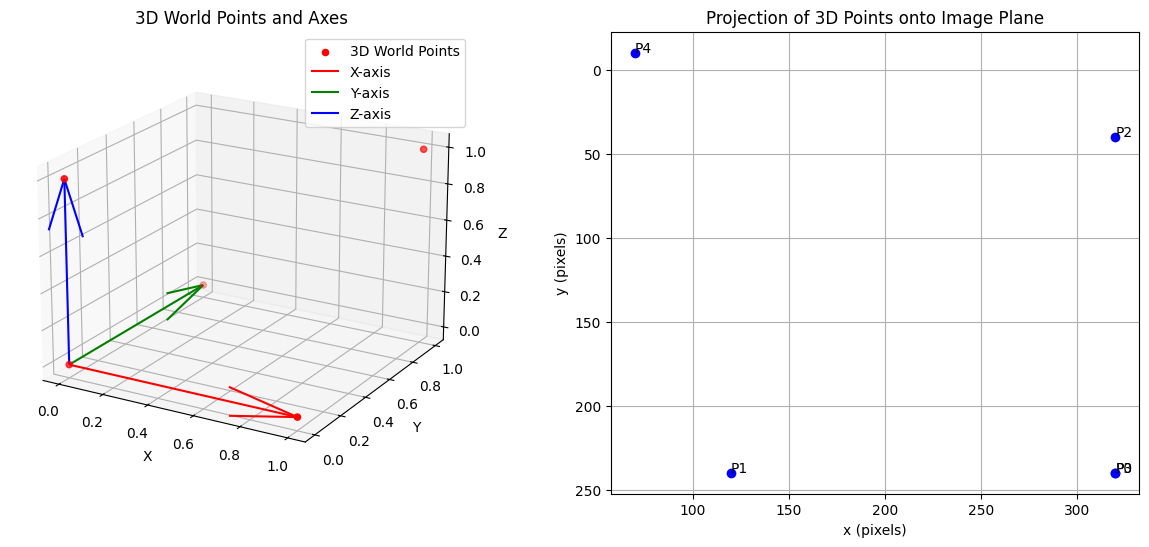

In [25]:
fig = plt.figure(figsize=(15, 6))
# 🌍 Subplot 1: 3D World Coordinate System
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(*world_points, c='red', label='3D World Points')
ax1.quiver(0, 0, 0, 1, 0, 0, color='r', label='X-axis')
ax1.quiver(0, 0, 0, 0, 1, 0, color='g', label='Y-axis')
ax1.quiver(0, 0, 0, 0, 0, 1, color='b', label='Z-axis')
ax1.set_title("3D World Points and Axes")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.legend()
ax1.view_init(20, -60)

# 📷 Subplot 2: 2D Image Projection
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(image_points[0], image_points[1], c='blue')
for i in range(image_points.shape[1]):
    ax2.annotate(f"P{i}", (image_points[0, i], image_points[1, i]))
ax2.set_title("Projection of 3D Points onto Image Plane")
ax2.set_xlabel("x (pixels)")
ax2.set_ylabel("y (pixels)")
ax2.grid(True)
ax2.invert_yaxis() # Typical image coordinate convention
plt.show()

🔹 Section 5: Visualize Camera Center

      Formula:
          C = -R^T * t
      
      Importance:
        # Represents the origin of rays from camera; essential in triangulation & reconstruction.

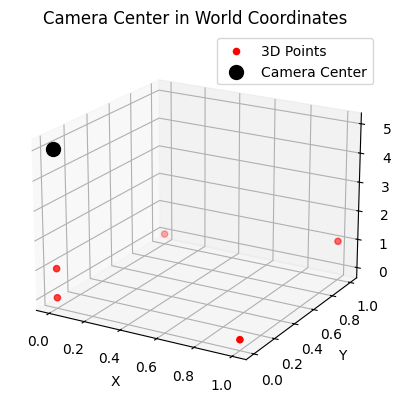

In [26]:
camera_center = -R.T @ t

# Visualize camera center in world
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(*world_points, color='red', label='3D Points')
ax.scatter(*camera_center.ravel(), color='black', s=100, label='Camera Center')
ax.set_title("Camera Center in World Coordinates")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
ax.view_init(20, -60)
plt.show()

🔹 Section 6: Vanishing Points

    Definition:
        Points where parallel lines in 3D appear to converge in 2D.
    Formula:
        v = P * [direction vector, 0]^T
    Importance:
        Used in perspective analysis, single-view metrology, calibration.

X-axis vanishing point lies at infinity and cannot be plotted.
Y-axis vanishing point lies at infinity and cannot be plotted.


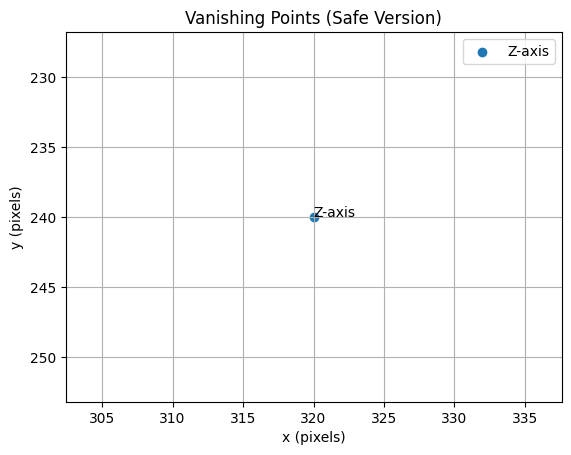

In [27]:
directions = {
    'X-axis': np.array([1, 0, 0, 0]),
    'Y-axis': np.array([0, 1, 0, 0]),
    'Z-axis': np.array([0, 0, 1, 0])
}

vanishing_pts = {}

plt.figure()
for axis, d in directions.items():
    v = P @ d
    if np.abs(v[2]) > 1e-6:  # Avoid division by zero
        v /= v[2]
        vanishing_pts[axis] = v[:2]
        plt.scatter(*v[:2], label=axis)
        plt.annotate(axis, (v[0], v[1]))
    else:
        print(f"{axis} vanishing point lies at infinity and cannot be plotted.")

plt.title("Vanishing Points (Safe Version)")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.grid(True)
plt.legend()
plt.gca().invert_yaxis()
plt.show()


Section 7: Projection Ray Visualization

    Definition:
        A ray in 3D space that connects the camera center to an image point.

    Formula:
         direction = M⁻¹ * x
         point on ray = camera center

    Importance:
        Used in triangulation, 3D reconstruction from image points.

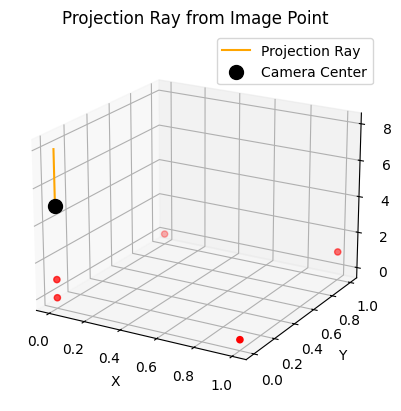

In [28]:
x_img = np.array([320, 240, 1])  # center pixel
M = P[:, :3]
p4 = P[:, 3]
M_inv = np.linalg.inv(M)
ray_dir = M_inv @ x_img
ray_dir /= np.linalg.norm(ray_dir) # Normalize

# Line from camera center along ray
t_vals = np.linspace(0, 3, 10)
ray = camera_center + ray_dir.reshape(3, 1) * t_vals

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(ray[0], ray[1], ray[2], label="Projection Ray", color='orange')
ax.scatter(*camera_center.ravel(), color='black', s=100, label='Camera Center')
ax.scatter(*world_points, color='red')
ax.set_title("Projection Ray from Image Point")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
ax.view_init(20, -60)
plt.show()

🔹 Section 8: Plane from Image Line and Camera Center

    Formula:
        π = Pᵗ * l  where l is an image line

    Importance:
        # Represents 3D plane passing through camera and a line in image.
        # Useful in scene reconstruction and computing epipolar planes.

In [29]:
# Assume an image line l (e.g., horizontal edge)
l = np.array([1, -1, 0]) # Sample image line
plane = P.T @ l

print("Plane from image line l:\n", plane.ravel())

Plane from image line l:
 [ 1000. -1000.    80.  -400.]


🔹 Section 9: Vanishing Point from 3D direction

    Formula:
        v = M * d

    Importance:
        Used in projective geometry to find direction-based intersections.

In [31]:
d = np.array([1, 1, 0])  # Direction parallel to image plane (no Z depth)

vp_d = M @ d  # 3x1 vector
if np.abs(vp_d[2]) > 1e-6:
    vp_d /= vp_d[2]
    print("Vanishing Point for direction [1,1,0]:", vp_d[:2])
else:
    print("Vanishing point for direction [1,1,0] lies at infinity and cannot be plotted.")


Vanishing point for direction [1,1,0] lies at infinity and cannot be plotted.
